In [1]:
!pip install pmdarima

In [2]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA
import pmdarima as pm #auto arima

## 1. Read in the monthly anti-diabetic drug sales in Australia dataset

The dataset is included in this repository as `drug_sales_australia.csv` and is loaded directly from the project directory.

In [3]:
drug_sales_df = pd.read_csv(
    "drug_sales_australia.csv",
    parse_dates=["date"],
    index_col=["date"]
)

drug_sales_df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


In [4]:
'''
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
drug_sales_df['value'].plot(label='Monthly anti-diabetic drug sales in Australia', color='blue')

# adding title to the plot
plt.title('Monthly anti-diabetic drug sales in Australia from {} to {}'.format('1991-07-01', '2008-06-01'))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()
'''

"\n# Visualizing the series\n\n# to set the plot size\nplt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.\n\n# in plot method we set the label and color of the curve.\ndrug_sales_df['value'].plot(label='Monthly anti-diabetic drug sales in Australia', color='blue')\n\n# adding title to the plot\nplt.title('Monthly anti-diabetic drug sales in Australia from {} to {}'.format('1991-07-01', '2008-06-01'))\n\n# adding Label to the x-axis\nplt.xlabel('Date')\n\n# adding legend to the curve\nplt.legend()\n"

In [5]:
drug_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 1991-07-01 to 2008-06-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   204 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


## 2. Exploratory Data Analysis (EDA)


In [6]:
# 1. Descriptive Statistics
drug_sales_df.describe()

,value
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


<Axes: >

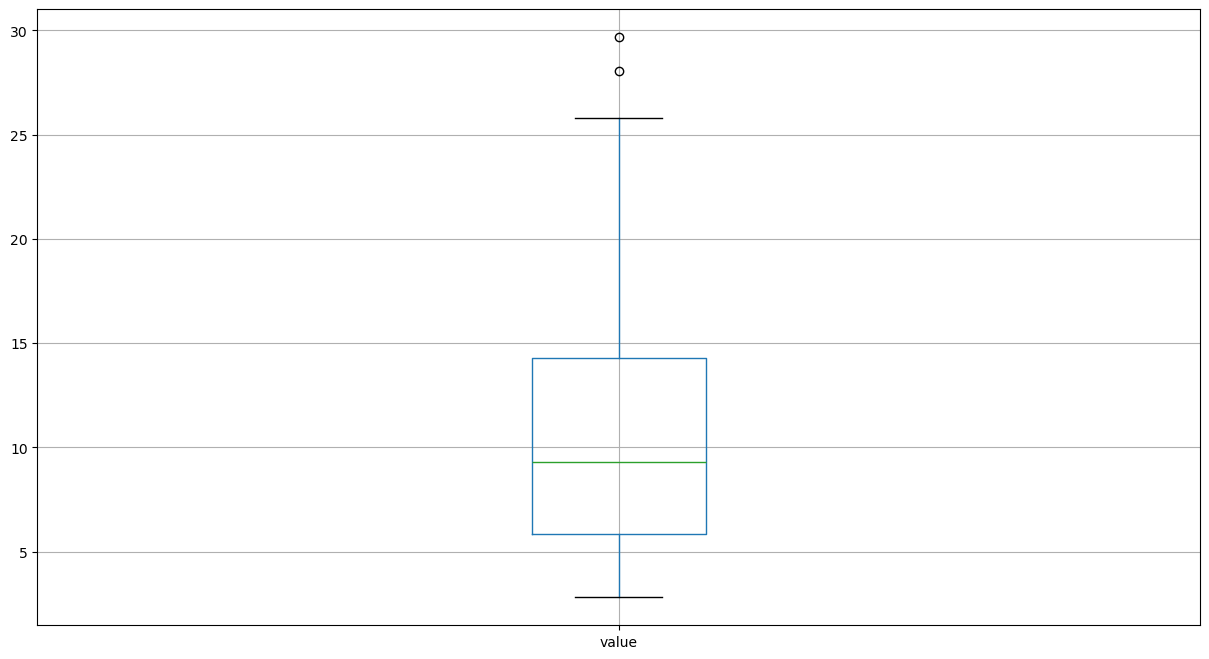

In [7]:
plt.figure(figsize=(15,8))
drug_sales_df.boxplot()

In [8]:
# 2. Check for missing values
drug_sales_df.isnull().sum()

value    0
dtype: int64

In [9]:
# 3. Find the indexes that are missing
pd.date_range(start = drug_sales_df.index.min(), end = drug_sales_df.index.max(), freq='MS').difference(drug_sales_df.index)


DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

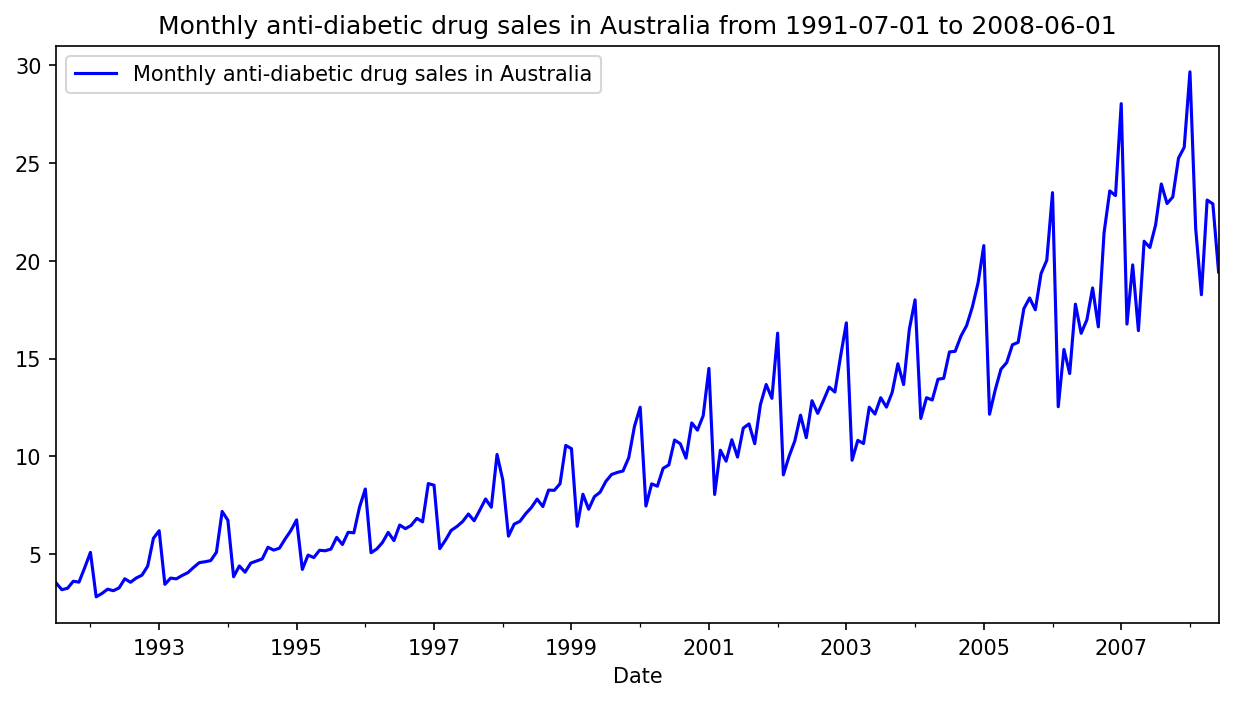

In [10]:
# Visualizing the series

# to set the plot size
plt.figure(figsize=(10, 5), dpi=150) #dpi = resolution. default 100.

# in plot method we set the label and color of the curve.
drug_sales_df['value'].plot(label='Monthly anti-diabetic drug sales in Australia', color='blue')

# adding title to the plot
plt.title('Monthly anti-diabetic drug sales in Australia from {} to {}'.format('1991-07-01', '2008-06-01'))

# adding Label to the x-axis
plt.xlabel('Date')

# adding legend to the curve
plt.legend()


## Stationarity

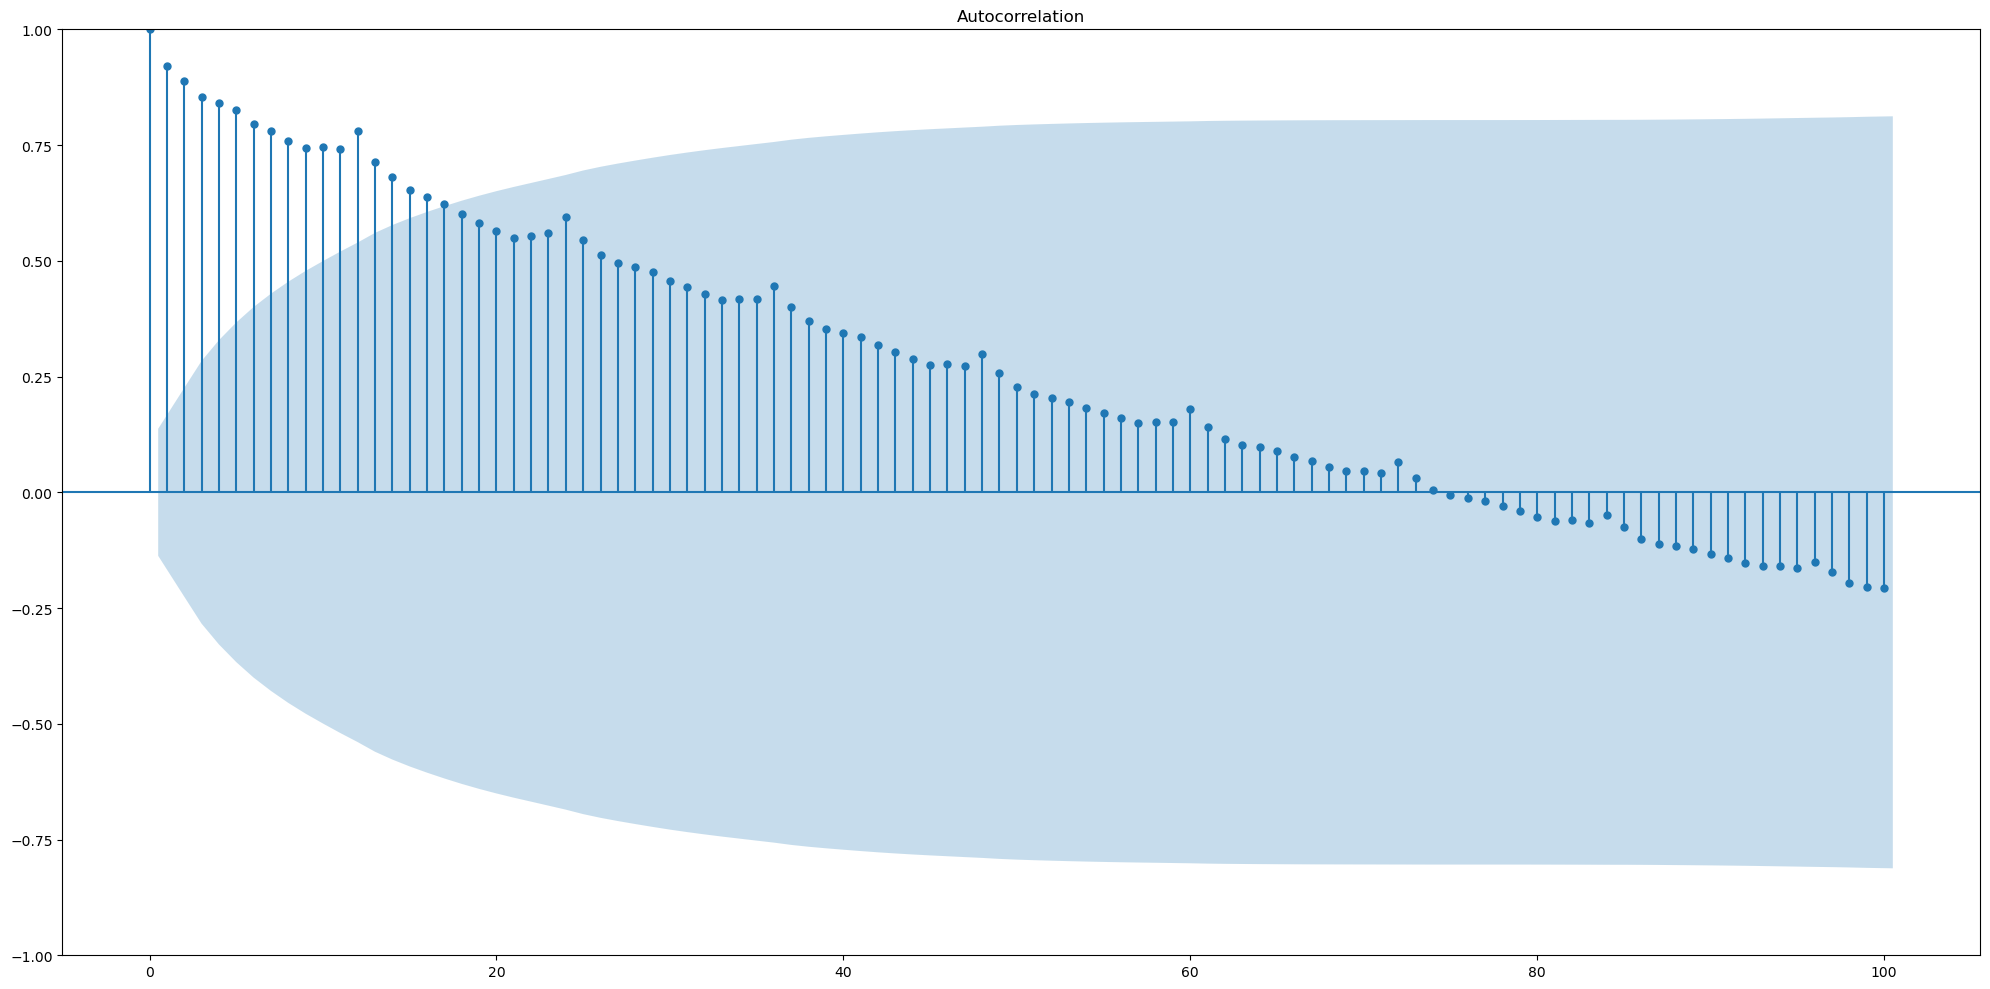

In [11]:
#check if the data is stationary

# autocorrelation plot of the dataset
fig = plot_acf(drug_sales_df, lags=100)
fig.set_size_inches((20, 10))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [12]:
#data has trend as well as seasonlity of 12 months

## Unit Root Test - Augmented Dickey-Fuller (ADF) statistical test to check stationarity

In [13]:
X = drug_sales_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: 3.145186
p-value: 1.000000
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575


/var/folders/gg/jrs0677j3dg1292v5xmr5fm80000gn/T/ipykernel_15625/3821393100.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Running the test prints the test statistic value of 3.14. The more negative this statistic, the more likely we are to reject the null hypothesis (we have a stationary dataset). As part of the output, we get a look-up table to help determine the ADF statistic. We can see that our statistic value of 3.14 is greater than the value of -2.87 at 5%. Also, the p-value is greater than 0.05.

This suggests that we fail to reject the null hypothesis with a significance level of 5%. Failing to reject the null hypothesis means that the process a unit root, and in turn that the time series is non-stationary.

## Differencing
One of the best ways to make a non-stationary time series stationary — compute the differences between consecutive observations. This is known as differencing.Transformations such as logarithms can help to stabilise the variance of a time series. Differencing can help stabilise the mean of a time series by removing changes in the level of a time series, and therefore eliminating (or reducing) trend and seasonality.

<Axes: xlabel='date'>

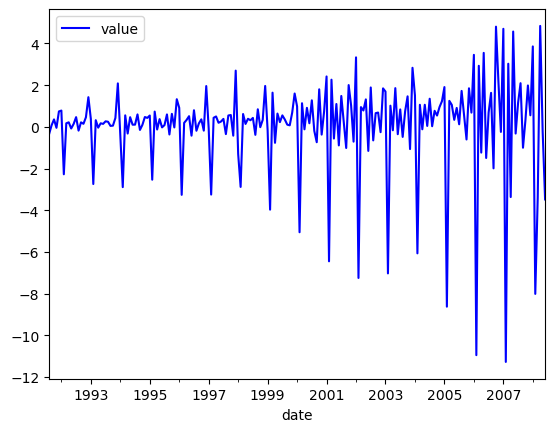

In [14]:
#create differenced dataset
first_diff_df = drug_sales_df.diff().dropna()
first_diff_df.plot(color='blue')

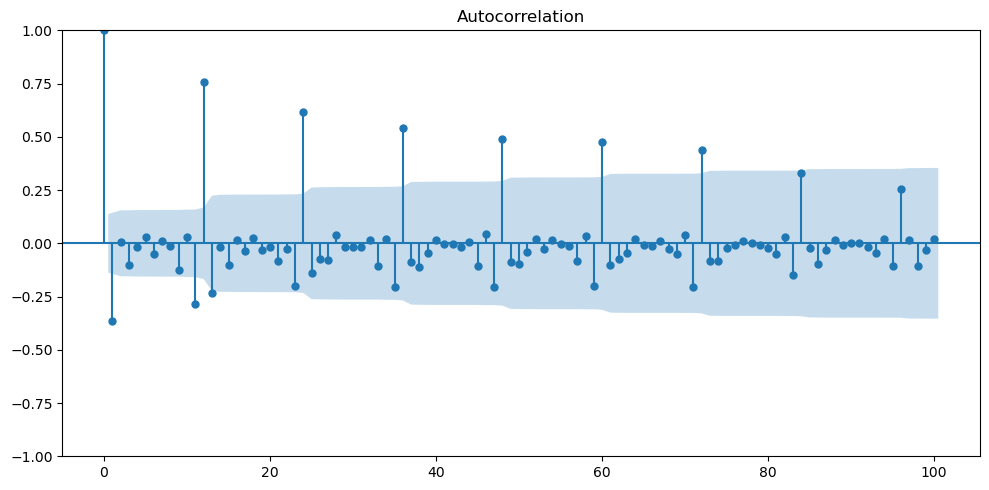

In [15]:
# autocorrelation plot of differenced dataset
fig = plot_acf(first_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [16]:
X = first_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.495172
p-value: 0.116653
Critical Values:
	1%: -3.466
	5%: -2.877
	10%: -2.575


/var/folders/gg/jrs0677j3dg1292v5xmr5fm80000gn/T/ipykernel_15625/1110963401.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


From the ACF and line plot and the ADF test p-value we can deduce that the series is non-stationary. As we can see a seasonal pattern, let us apply seasonal differencing.

<Axes: xlabel='date'>

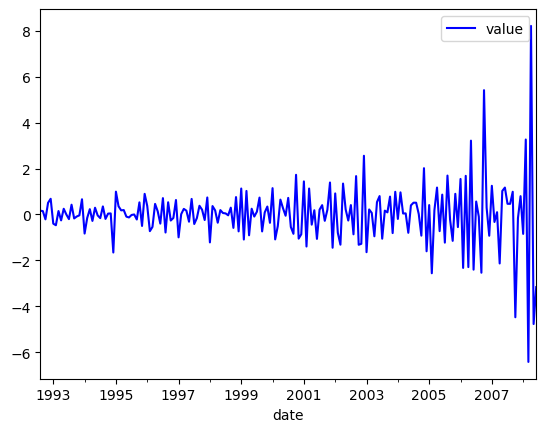

In [17]:
seasonal_diff_df = first_diff_df.diff(12).dropna()
seasonal_diff_df.plot(color = 'blue')

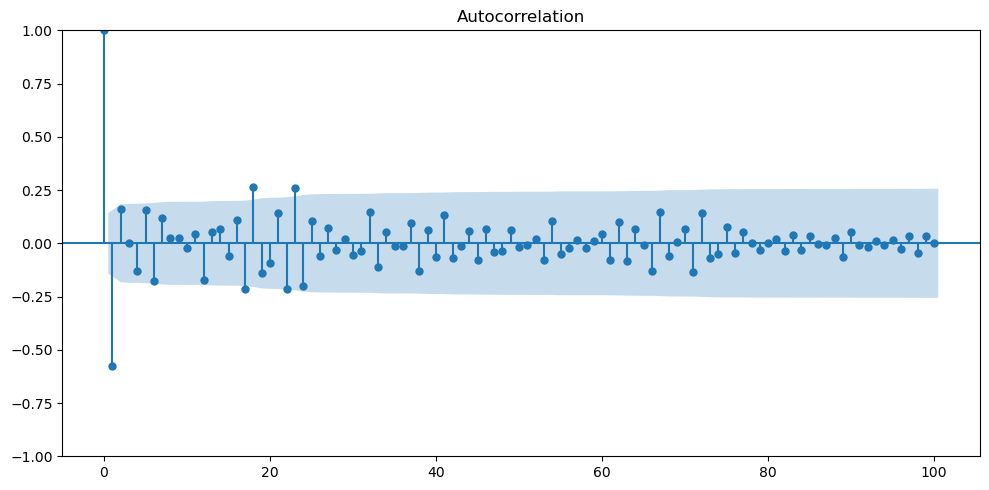

In [18]:
# autocorrelation plot of the seasonaly differenced dataset
fig = plot_acf(seasonal_diff_df, lags=100)
fig.set_size_inches((10, 5))
# Tight layout to realign things
fig.tight_layout()
plt.show()

In [19]:
X = seasonal_diff_df.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.783440
p-value: 0.000058
Critical Values:
	1%: -3.468
	5%: -2.878
	10%: -2.576


/var/folders/gg/jrs0677j3dg1292v5xmr5fm80000gn/T/ipykernel_15625/509688674.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(X)


Since p-value is less than 0.05 we can reject the null hypothesis and the data is stationary.

# Part 2 - Backtesting Periods

Four 12-month backtest periods are used:

1. July 2004 - June 2005
2. July 2005 - June 2006
3. July 2006 - June 2007
4. July 2007 - June 2008

In [20]:
drug_sales_df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


In [21]:
# Backtest 1: July 2004 - June 2005

train_bt1 = drug_sales_df.loc[:'2004-06-01']
test_bt1 = drug_sales_df.loc['2004-07-01':'2005-06-01']

print("Backtest 1")
print("Train:", train_bt1.index.min(), "to", train_bt1.index.max())
print("Test:", test_bt1.index.min(), "to", test_bt1.index.max())
print("Number of test observations:", len(test_bt1))

Backtest 1
Train: 1991-07-01 00:00:00 to 2004-06-01 00:00:00
Test: 2004-07-01 00:00:00 to 2005-06-01 00:00:00
Number of test observations: 12


In [22]:
# train_bt1

In [23]:
# test_bt1

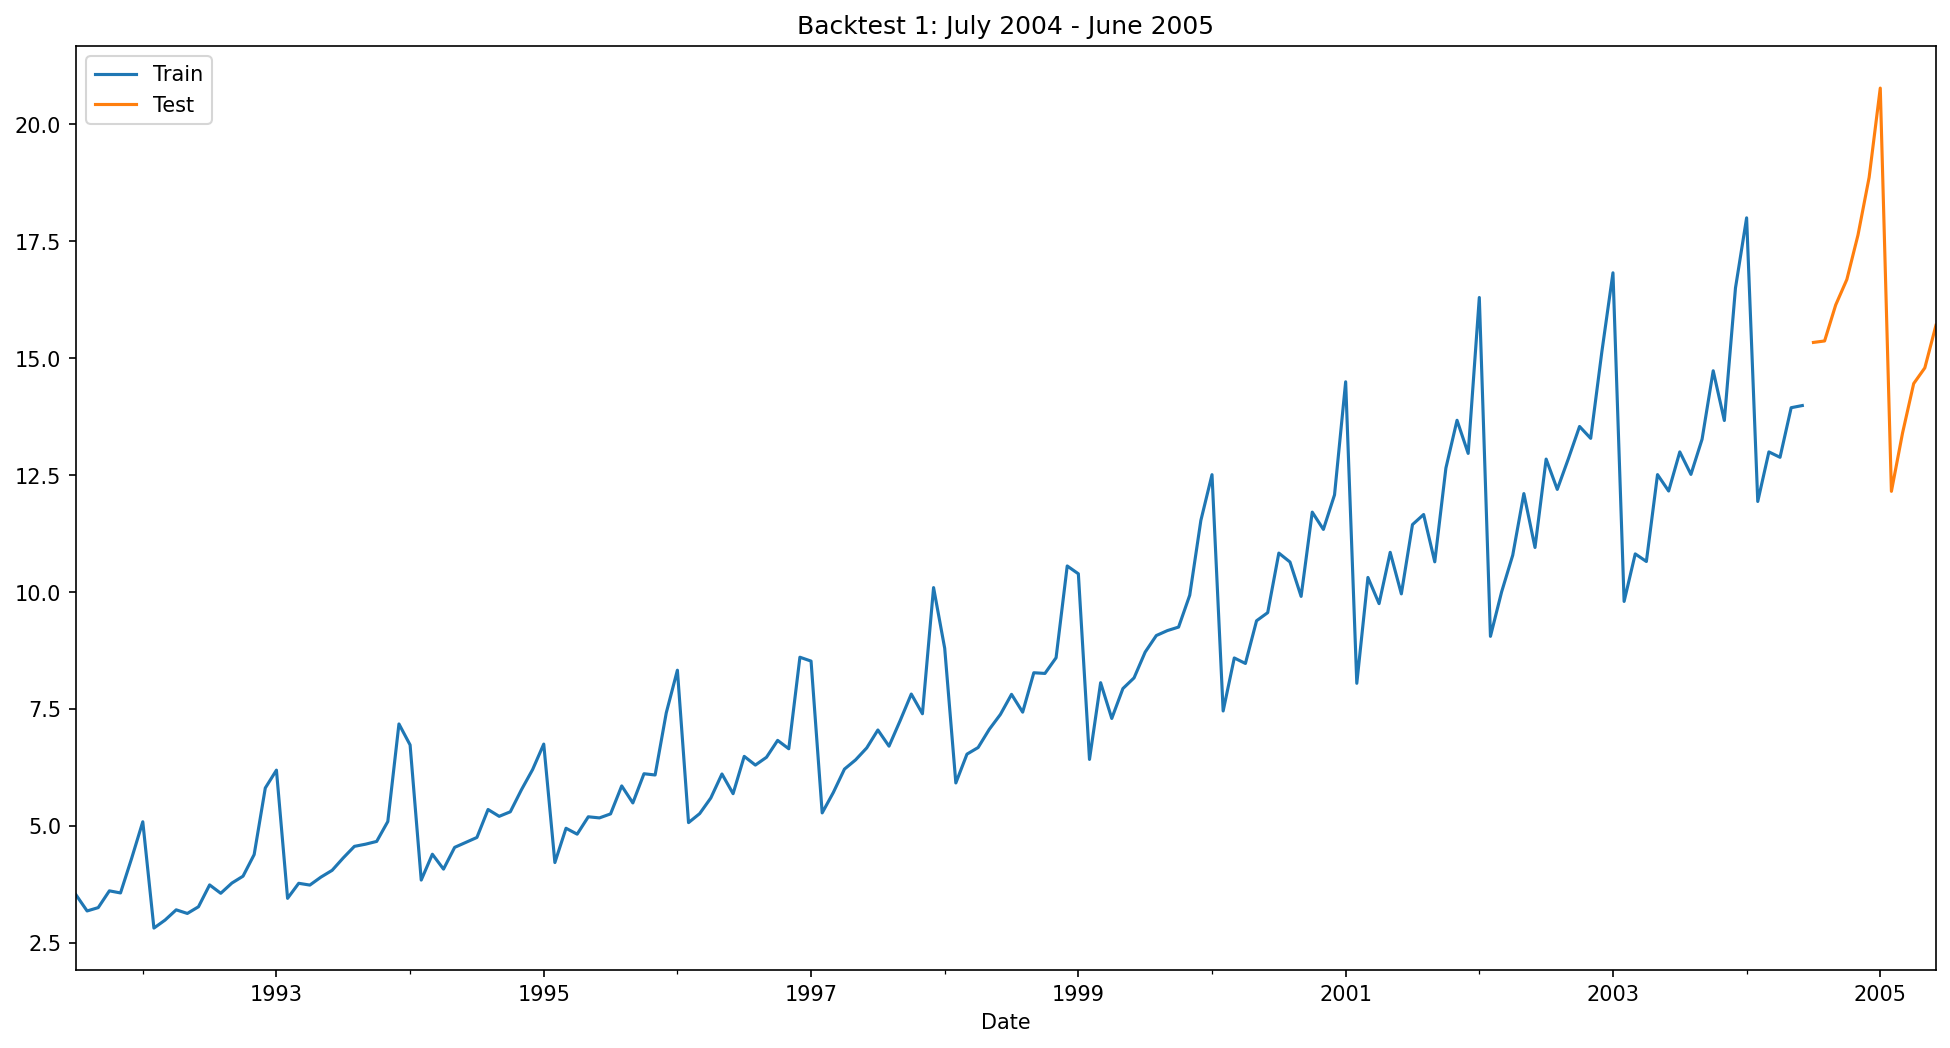

In [24]:
plt.figure(figsize=(16, 8), dpi=150)

train_bt1['value'].plot(label='Train')
test_bt1['value'].plot(label='Test')

plt.xlabel('Date')
plt.title('Backtest 1: July 2004 - June 2005')
plt.legend()

plt.show()

In [25]:
# Backtest 2: July 2005 - June 2006

train_bt2 = drug_sales_df.loc[:'2005-06-01']
test_bt2 = drug_sales_df.loc['2005-07-01':'2006-06-01']

print("Backtest 2")
print("Train:", train_bt2.index.min(), "to", train_bt2.index.max())
print("Test:", test_bt2.index.min(), "to", test_bt2.index.max())
print("Number of test observations:", len(test_bt2))

Backtest 2
Train: 1991-07-01 00:00:00 to 2005-06-01 00:00:00
Test: 2005-07-01 00:00:00 to 2006-06-01 00:00:00
Number of test observations: 12


In [26]:
# Backtest 3: July 2006 - June 2007

train_bt3 = drug_sales_df.loc[:'2006-06-01']
test_bt3 = drug_sales_df.loc['2006-07-01':'2007-06-01']

print("Backtest 3")
print("Train:", train_bt3.index.min(), "to", train_bt3.index.max())
print("Test:", test_bt3.index.min(), "to", test_bt3.index.max())
print("Number of test observations:", len(test_bt3))

Backtest 3
Train: 1991-07-01 00:00:00 to 2006-06-01 00:00:00
Test: 2006-07-01 00:00:00 to 2007-06-01 00:00:00
Number of test observations: 12


In [27]:
# Backtest 4: July 2007 - June 2008

train_bt4 = drug_sales_df.loc[:'2007-06-01']
test_bt4 = drug_sales_df.loc['2007-07-01':'2008-06-01']

print("Backtest 4")
print("Train:", train_bt4.index.min(), "to", train_bt4.index.max())
print("Test:", test_bt4.index.min(), "to", test_bt4.index.max())
print("Number of test observations:", len(test_bt4))

Backtest 4
Train: 1991-07-01 00:00:00 to 2007-06-01 00:00:00
Test: 2007-07-01 00:00:00 to 2008-06-01 00:00:00
Number of test observations: 12


In [28]:
backtest_summary = pd.DataFrame({
    'Backtest': ['BT1', 'BT2', 'BT3', 'BT4'],
    'Train End': [
        train_bt1.index.max(),
        train_bt2.index.max(),
        train_bt3.index.max(),
        train_bt4.index.max()
    ],
    'Test Start': [
        test_bt1.index.min(),
        test_bt2.index.min(),
        test_bt3.index.min(),
        test_bt4.index.min()
    ],
    'Test End': [
        test_bt1.index.max(),
        test_bt2.index.max(),
        test_bt3.index.max(),
        test_bt4.index.max()
    ],
    'Test Observations': [
        len(test_bt1),
        len(test_bt2),
        len(test_bt3),
        len(test_bt4)
    ]
})

backtest_summary

,Backtest,Train End,Test Start,Test End,Test Observations
0,BT1,2004-06-01,2004-07-01,2005-06-01,12
1,BT2,2005-06-01,2005-07-01,2006-06-01,12
2,BT3,2006-06-01,2006-07-01,2007-06-01,12
3,BT4,2007-06-01,2007-07-01,2008-06-01,12


# Part 3 - ETS and ARIMA Model Evaluation

In [29]:
backtests = [
    ('BT1', train_bt1, test_bt1),
    ('BT2', train_bt2, test_bt2),
    ('BT3', train_bt3, test_bt3),
    ('BT4', train_bt4, test_bt4)
]

In [30]:
arima_results = []
arima_forecasts = []

In [31]:
for bt_name, train, test in backtests:

    nonseasonal_model = pm.auto_arima(
        train['value'],
        start_p=0,
        start_q=0,
        test='adf',
        max_p=3,
        max_q=3,
        d=None,
        seasonal=False,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    nonseasonal_forecast = nonseasonal_model.predict(n_periods=12)

    actual = test['value'].values

    rmse = sqrt(mean_squared_error(actual, nonseasonal_forecast))
    mae = mean_absolute_error(actual, nonseasonal_forecast)
    mape = np.mean(
        np.abs((actual - nonseasonal_forecast) / actual)
    ) * 100

    arima_results.append({
        'Backtest': bt_name,
        'Model': 'Non-seasonal Auto ARIMA',
        'Selected Order': str(nonseasonal_model.order),
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Backtest': bt_name,
        'Model': 'Non-seasonal Auto ARIMA',
        'Actual': actual,
        'Forecast': nonseasonal_forecast
    })

    arima_forecasts.append(forecast_df)

The original search took too long to run, so I reduced the parameter range based on the model orders selected in the earlier backtests while still keeping the most relevant values.

In [32]:
for bt_name, train, test in backtests:

    seasonal_model = pm.auto_arima(
        train['value'],
        start_p=0,
        start_q=0,
        test='adf',

        max_p=2,
        max_q=2,

        m=12,

        start_P=0,
        start_Q=0,
        max_P=1,
        max_Q=2,

        seasonal=True,
        d=None,
        D=1,

        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    seasonal_forecast = seasonal_model.predict(n_periods=12)

    actual = test['value'].values

    rmse = sqrt(mean_squared_error(actual, seasonal_forecast))
    mae = mean_absolute_error(actual, seasonal_forecast)
    mape = np.mean(
        np.abs((actual - seasonal_forecast) / actual)
    ) * 100

    arima_results.append({
        'Backtest': bt_name,
        'Model': 'Seasonal Auto ARIMA',
        'Selected Order': str(seasonal_model.order) +
                          str(seasonal_model.seasonal_order),
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Backtest': bt_name,
        'Model': 'Seasonal Auto ARIMA',
        'Actual': actual,
        'Forecast': seasonal_forecast
    })

    arima_forecasts.append(forecast_df)

In [33]:
# print("Selected Order:", seasonal_model.order)
# print("Selected Seasonal Order:", seasonal_model.seasonal_order)

In [34]:
pd.DataFrame(arima_results)

,Backtest,Model,Selected Order,RMSE,MAE,MAPE
0,BT1,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.192067,2.562634,14.941777
1,BT2,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.413987,2.675261,14.452221
2,BT3,Non-seasonal Auto ARIMA,"(2, 0, 3)",4.879750,3.747028,16.579459
3,BT4,Non-seasonal Auto ARIMA,"(3, 0, 2)",4.261572,3.545356,14.481023
4,BT1,Seasonal Auto ARIMA,"(0, 1, 1)(0, 1, 2, 12)",1.147901,1.014928,6.306328
5,BT2,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 1, 12)",1.120222,0.977263,5.632365
6,BT3,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 2, 12)",2.615179,2.343023,11.295787
7,BT4,Seasonal Auto ARIMA,"(2, 1, 1)(1, 1, 2, 12)",2.287347,1.852809,8.637490


## Visualizing ARIMA Forecasts

In [35]:
arima_forecasts_df = pd.concat(arima_forecasts, ignore_index=True)

arima_forecasts_df.head()

,Date,Backtest,Model,Actual,Forecast
0,2004-07-01,BT1,Non-seasonal Auto ARIMA,15.339097,13.779698
1,2004-08-01,BT1,Non-seasonal Auto ARIMA,15.370764,13.715521
2,2004-09-01,BT1,Non-seasonal Auto ARIMA,16.142005,13.692685
3,2004-10-01,BT1,Non-seasonal Auto ARIMA,16.685754,13.681589
4,2004-11-01,BT1,Non-seasonal Auto ARIMA,17.636728,13.673829


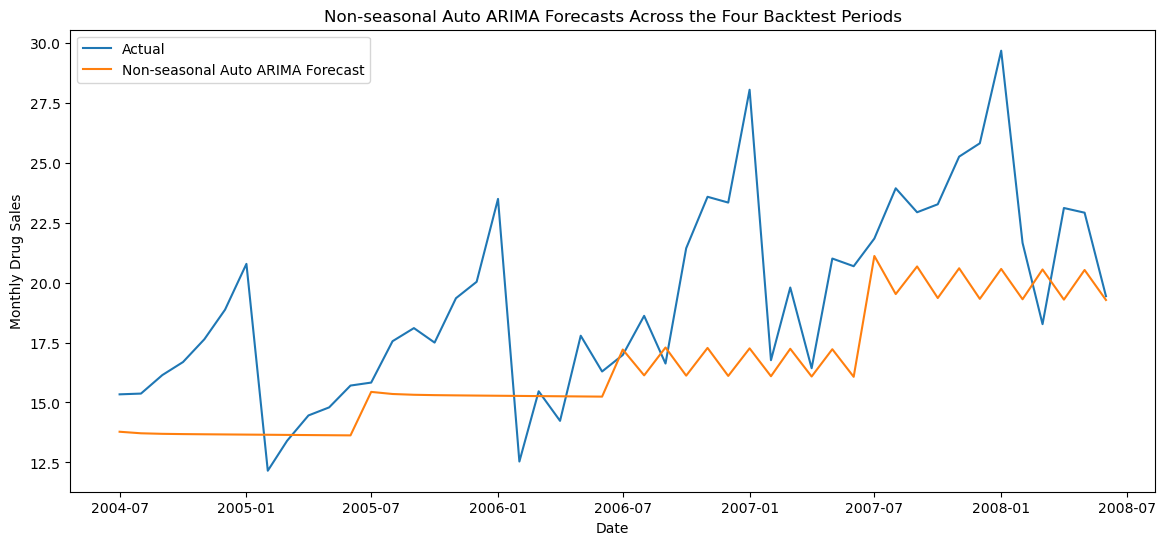

In [36]:
nonseasonal_plot_df = arima_forecasts_df[
    arima_forecasts_df['Model'] == 'Non-seasonal Auto ARIMA'
]

plt.figure(figsize=(14, 6))

plt.plot(
    nonseasonal_plot_df['Date'],
    nonseasonal_plot_df['Actual'],
    label='Actual'
)

plt.plot(
    nonseasonal_plot_df['Date'],
    nonseasonal_plot_df['Forecast'],
    label='Non-seasonal Auto ARIMA Forecast'
)

plt.title('Non-seasonal Auto ARIMA Forecasts Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

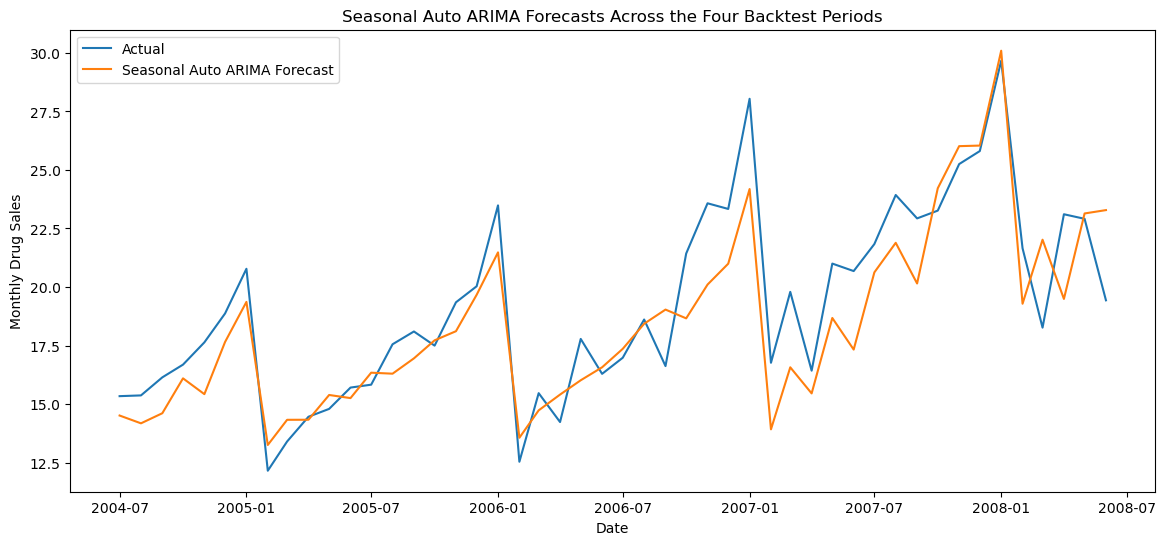

In [37]:
seasonal_plot_df = arima_forecasts_df[
    arima_forecasts_df['Model'] == 'Seasonal Auto ARIMA'
]

plt.figure(figsize=(14, 6))

plt.plot(
    seasonal_plot_df['Date'],
    seasonal_plot_df['Actual'],
    label='Actual'
)

plt.plot(
    seasonal_plot_df['Date'],
    seasonal_plot_df['Forecast'],
    label='Seasonal Auto ARIMA Forecast'
)

plt.title('Seasonal Auto ARIMA Forecasts Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

In [38]:
# ARIMA Backtest Results
arima_results_df = pd.DataFrame(arima_results)

arima_results_df

,Backtest,Model,Selected Order,RMSE,MAE,MAPE
0,BT1,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.192067,2.562634,14.941777
1,BT2,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.413987,2.675261,14.452221
2,BT3,Non-seasonal Auto ARIMA,"(2, 0, 3)",4.879750,3.747028,16.579459
3,BT4,Non-seasonal Auto ARIMA,"(3, 0, 2)",4.261572,3.545356,14.481023
4,BT1,Seasonal Auto ARIMA,"(0, 1, 1)(0, 1, 2, 12)",1.147901,1.014928,6.306328
5,BT2,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 1, 12)",1.120222,0.977263,5.632365
6,BT3,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 2, 12)",2.615179,2.343023,11.295787
7,BT4,Seasonal Auto ARIMA,"(2, 1, 1)(1, 1, 2, 12)",2.287347,1.852809,8.637490


In [39]:
arima_summary = (
    arima_results_df
    .groupby('Model')[['RMSE', 'MAE', 'MAPE']]
    .mean()
)

arima_summary

,RMSE,MAE,MAPE
Model,,,
Non-seasonal Auto ARIMA,3.936844,3.132570,15.113620
Seasonal Auto ARIMA,1.792662,1.547006,7.967992


Across all four backtest periods, the Seasonal Auto ARIMA model consistently produced lower RMSE, MAE, and MAPE than the Non-seasonal Auto ARIMA model, indicating that accounting for annual seasonality substantially improved forecast accuracy.

## ETS Model Evaluation

Three ETS models are evaluated across the four backtest periods:

1. Double Exponential Smoothing
2. Triple Exponential Smoothing with Additive Seasonality
3. Triple Exponential Smoothing with Multiplicative Seasonality

Because the data shows a clear trend and strong annual seasonality, the double exponential smoothing model is used as a non-seasonal baseline, while the two triple exponential smoothing models explicitly account for seasonality.

In [40]:
ets_results = []
ets_forecasts = []

In [41]:
# Double Exponential Smoothing
for bt_name, train, test in backtests:

    double_ets_model = ExponentialSmoothing(
        train['value'],
        trend='add',
        seasonal=None
    ).fit()

    double_ets_forecast = double_ets_model.forecast(12)

    actual = test['value'].values

    rmse = sqrt(mean_squared_error(actual, double_ets_forecast))
    mae = mean_absolute_error(actual, double_ets_forecast)
    mape = np.mean(
        np.abs((actual - double_ets_forecast) / actual)
    ) * 100

    ets_results.append({
        'Backtest': bt_name,
        'Model': 'Double Exponential Smoothing',
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Backtest': bt_name,
        'Model': 'Double Exponential Smoothing',
        'Actual': actual,
        'Forecast': double_ets_forecast.values
    })

    ets_forecasts.append(forecast_df)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
pd.DataFrame(ets_results)

,Backtest,Model,RMSE,MAE,MAPE
0,BT1,Double Exponential Smoothing,2.532282,1.999902,12.092794
1,BT2,Double Exponential Smoothing,2.902853,2.303359,13.254270
2,BT3,Double Exponential Smoothing,3.840680,2.931648,13.278890
3,BT4,Double Exponential Smoothing,3.601469,2.946270,12.280956


In [43]:
# Triple Exponential Smoothing with Additive Seasonality
for bt_name, train, test in backtests:

    triple_add_model = ExponentialSmoothing(
        train['value'],
        trend='add',
        seasonal='add',
        seasonal_periods=12
    ).fit(method='least_squares')

    triple_add_forecast = triple_add_model.forecast(12)

    actual = test['value'].values

    rmse = sqrt(mean_squared_error(actual, triple_add_forecast))
    mae = mean_absolute_error(actual, triple_add_forecast)
    mape = np.mean(
        np.abs((actual - triple_add_forecast) / actual)
    ) * 100

    ets_results.append({
        'Backtest': bt_name,
        'Model': 'Triple ETS - Additive Seasonality',
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Backtest': bt_name,
        'Model': 'Triple ETS - Additive Seasonality',
        'Actual': actual,
        'Forecast': triple_add_forecast.values
    })

    ets_forecasts.append(forecast_df)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [44]:
pd.DataFrame(ets_results)

,Backtest,Model,RMSE,MAE,MAPE
0,BT1,Double Exponential Smoothing,2.532282,1.999902,12.092794
1,BT2,Double Exponential Smoothing,2.902853,2.303359,13.254270
2,BT3,Double Exponential Smoothing,3.840680,2.931648,13.278890
3,BT4,Double Exponential Smoothing,3.601469,2.946270,12.280956
4,BT1,Triple ETS - Additive Seasonality,1.041157,0.933422,5.843475
5,BT2,Triple ETS - Additive Seasonality,1.122237,0.987616,5.665803
6,BT3,Triple ETS - Additive Seasonality,2.434015,2.165078,10.456202
7,BT4,Triple ETS - Additive Seasonality,2.174534,1.863436,8.538171


In [45]:
# Triple Exponential Smoothing with Multiplicative Seasonality
for bt_name, train, test in backtests:

    triple_mul_model = ExponentialSmoothing(
        train['value'],
        trend='add',
        seasonal='mul',
        seasonal_periods=12
    ).fit()

    triple_mul_forecast = triple_mul_model.forecast(12)

    actual = test['value'].values

    rmse = sqrt(mean_squared_error(actual, triple_mul_forecast))
    mae = mean_absolute_error(actual, triple_mul_forecast)
    mape = np.mean(
        np.abs((actual - triple_mul_forecast) / actual)
    ) * 100

    ets_results.append({
        'Backtest': bt_name,
        'Model': 'Triple ETS - Multiplicative Seasonality',
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    forecast_df = pd.DataFrame({
        'Date': test.index,
        'Backtest': bt_name,
        'Model': 'Triple ETS - Multiplicative Seasonality',
        'Actual': actual,
        'Forecast': triple_mul_forecast.values
    })

    ets_forecasts.append(forecast_df)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferr

In [46]:
ets_results_df = pd.DataFrame(ets_results)

ets_results_df

,Backtest,Model,RMSE,MAE,MAPE
0,BT1,Double Exponential Smoothing,2.532282,1.999902,12.092794
1,BT2,Double Exponential Smoothing,2.902853,2.303359,13.254270
2,BT3,Double Exponential Smoothing,3.840680,2.931648,13.278890
3,BT4,Double Exponential Smoothing,3.601469,2.946270,12.280956
4,BT1,Triple ETS - Additive Seasonality,1.041157,0.933422,5.843475
5,BT2,Triple ETS - Additive Seasonality,1.122237,0.987616,5.665803
6,BT3,Triple ETS - Additive Seasonality,2.434015,2.165078,10.456202
7,BT4,Triple ETS - Additive Seasonality,2.174534,1.863436,8.538171
8,BT1,Triple ETS - Multiplicative Seasonality,0.801457,0.673547,4.159668
9,BT2,Triple ETS - Multiplicative Seasonality,0.977098,0.875064,5.102864


In [47]:
ets_forecasts_df = pd.concat(ets_forecasts, ignore_index=True)

ets_forecasts_df.head()

,Date,Backtest,Model,Actual,Forecast
0,2004-07-01,BT1,Double Exponential Smoothing,15.339097,14.474816
1,2004-08-01,BT1,Double Exponential Smoothing,15.370764,14.565683
2,2004-09-01,BT1,Double Exponential Smoothing,16.142005,14.656550
3,2004-10-01,BT1,Double Exponential Smoothing,16.685754,14.747417
4,2004-11-01,BT1,Double Exponential Smoothing,17.636728,14.838284


## ETS visualization

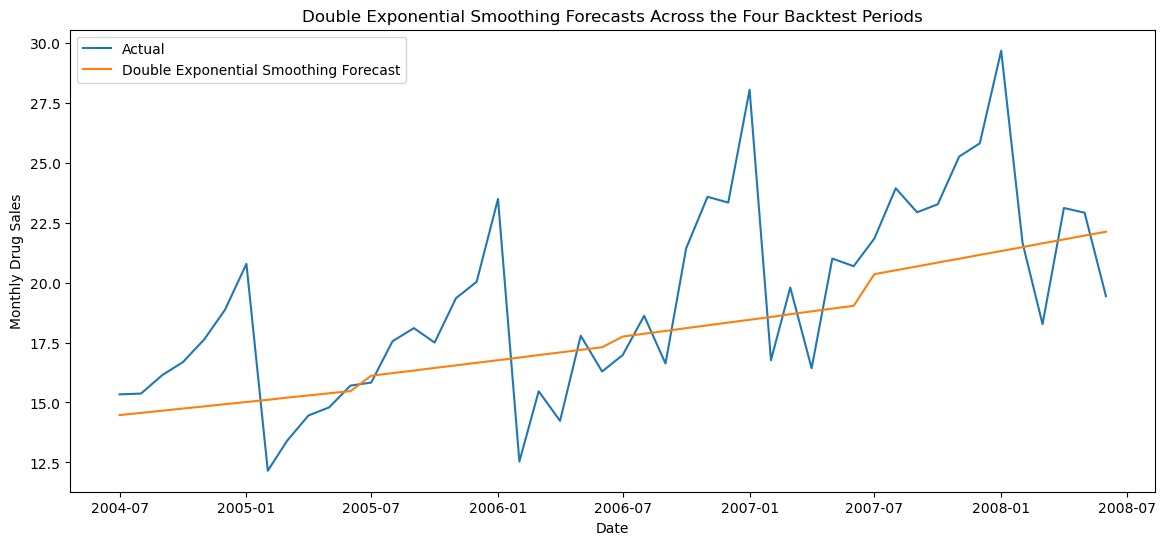

In [48]:
# Double Exponential Smoothing
double_plot_df = ets_forecasts_df[
    ets_forecasts_df['Model'] == 'Double Exponential Smoothing'
]

plt.figure(figsize=(14, 6))

plt.plot(
    double_plot_df['Date'],
    double_plot_df['Actual'],
    label='Actual'
)

plt.plot(
    double_plot_df['Date'],
    double_plot_df['Forecast'],
    label='Double Exponential Smoothing Forecast'
)

plt.title('Double Exponential Smoothing Forecasts Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

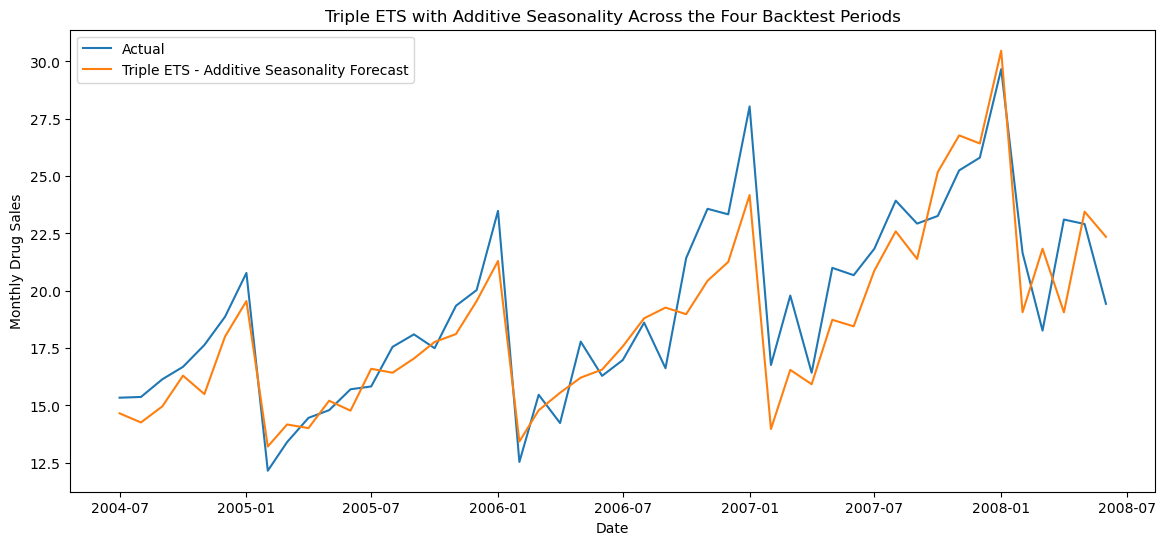

In [49]:
# Triple ETS — Additive Seasonality
triple_add_plot_df = ets_forecasts_df[
    ets_forecasts_df['Model'] == 'Triple ETS - Additive Seasonality'
]

plt.figure(figsize=(14, 6))

plt.plot(
    triple_add_plot_df['Date'],
    triple_add_plot_df['Actual'],
    label='Actual'
)

plt.plot(
    triple_add_plot_df['Date'],
    triple_add_plot_df['Forecast'],
    label='Triple ETS - Additive Seasonality Forecast'
)

plt.title('Triple ETS with Additive Seasonality Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

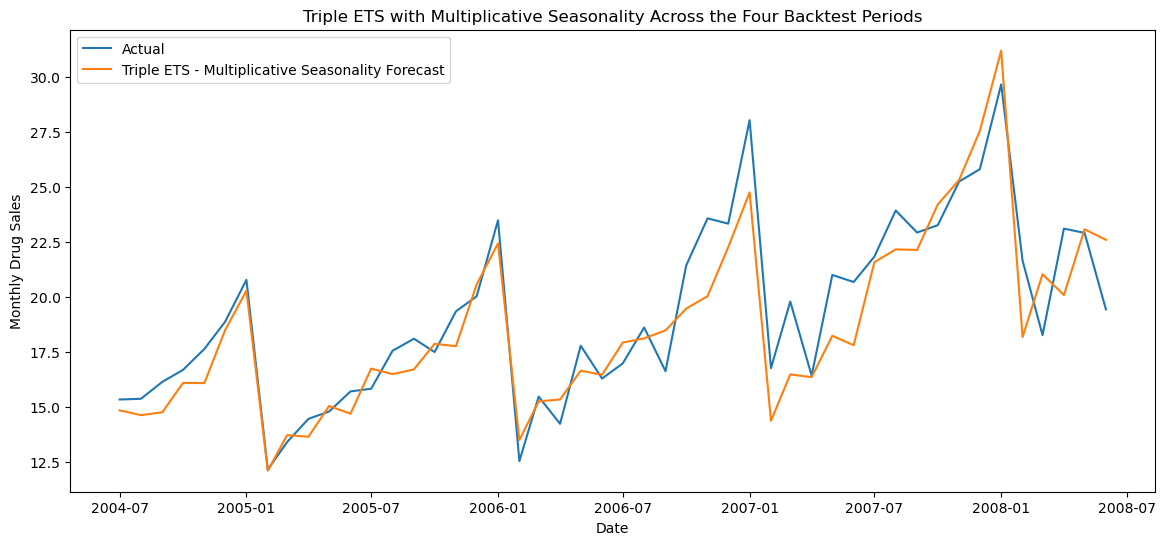

In [50]:
# Multiplicative
triple_mul_plot_df = ets_forecasts_df[
    ets_forecasts_df['Model'] == 'Triple ETS - Multiplicative Seasonality'
]

plt.figure(figsize=(14, 6))

plt.plot(
    triple_mul_plot_df['Date'],
    triple_mul_plot_df['Actual'],
    label='Actual'
)

plt.plot(
    triple_mul_plot_df['Date'],
    triple_mul_plot_df['Forecast'],
    label='Triple ETS - Multiplicative Seasonality Forecast'
)

plt.title('Triple ETS with Multiplicative Seasonality Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

### Since the additive and multiplicative ETS forecasts are very close, I plotted them together to make the differences easier to compare.

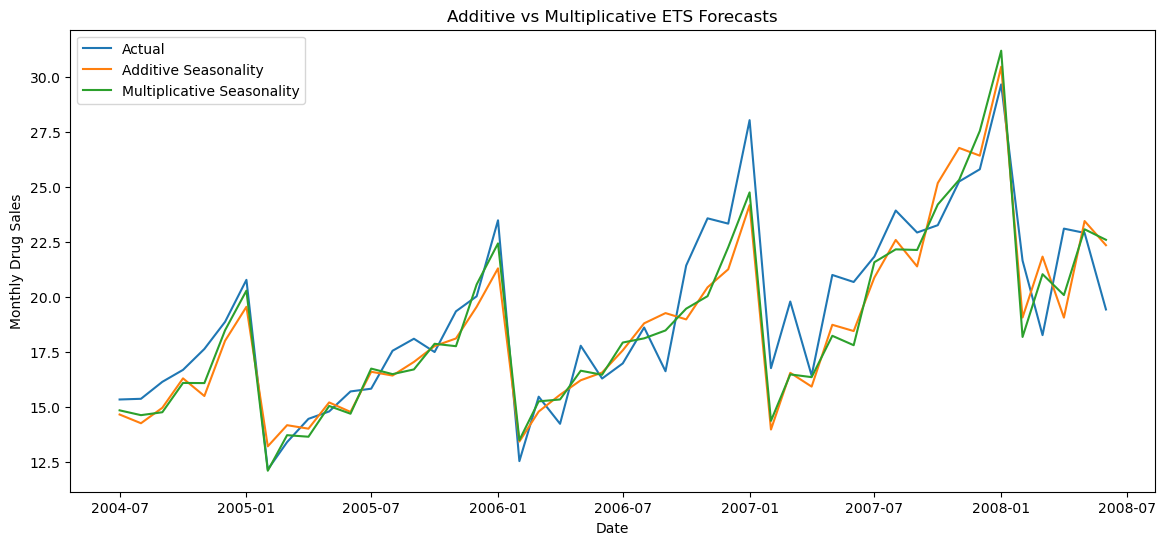

In [51]:
add_df = ets_forecasts_df[
    ets_forecasts_df['Model'] == 'Triple ETS - Additive Seasonality'
]

mul_df = ets_forecasts_df[
    ets_forecasts_df['Model'] == 'Triple ETS - Multiplicative Seasonality'
]

plt.figure(figsize=(14, 6))

plt.plot(
    add_df['Date'],
    add_df['Actual'],
    label='Actual'
)

plt.plot(
    add_df['Date'],
    add_df['Forecast'],
    label='Additive Seasonality'
)

plt.plot(
    mul_df['Date'],
    mul_df['Forecast'],
    label='Multiplicative Seasonality'
)

plt.title('Additive vs Multiplicative ETS Forecasts')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

In [52]:
ets_summary = (
    ets_results_df
    .groupby('Model')[['RMSE', 'MAE', 'MAPE']]
    .mean()
)

ets_summary

,RMSE,MAE,MAPE
Model,,,
Double Exponential Smoothing,3.219321,2.545295,12.726728
Triple ETS - Additive Seasonality,1.692986,1.487388,7.625913
Triple ETS - Multiplicative Seasonality,1.534000,1.309460,6.647890


# Part 4 - Model Comparison and Selection

The ARIMA and ETS models are compared across all four backtest periods using both visual performance and average forecast accuracy.

In [53]:
all_results_df = pd.concat(
    [arima_results_df, ets_results_df],
    ignore_index=True
)

all_results_df

,Backtest,Model,Selected Order,RMSE,MAE,MAPE
0,BT1,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.192067,2.562634,14.941777
1,BT2,Non-seasonal Auto ARIMA,"(2, 0, 1)",3.413987,2.675261,14.452221
2,BT3,Non-seasonal Auto ARIMA,"(2, 0, 3)",4.879750,3.747028,16.579459
3,BT4,Non-seasonal Auto ARIMA,"(3, 0, 2)",4.261572,3.545356,14.481023
4,BT1,Seasonal Auto ARIMA,"(0, 1, 1)(0, 1, 2, 12)",1.147901,1.014928,6.306328
5,BT2,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 1, 12)",1.120222,0.977263,5.632365
6,BT3,Seasonal Auto ARIMA,"(2, 0, 1)(0, 1, 2, 12)",2.615179,2.343023,11.295787
7,BT4,Seasonal Auto ARIMA,"(2, 1, 1)(1, 1, 2, 12)",2.287347,1.852809,8.637490
8,BT1,Double Exponential Smoothing,NaN,2.532282,1.999902,12.092794
9,BT2,Double Exponential Smoothing,NaN,2.902853,2.303359,13.254270


In [54]:
model_summary = (
    all_results_df
    .groupby('Model')[['RMSE', 'MAE', 'MAPE']]
    .mean()
    .sort_values('RMSE')
)

model_summary

,RMSE,MAE,MAPE
Model,,,
Triple ETS - Multiplicative Seasonality,1.534000,1.309460,6.647890
Triple ETS - Additive Seasonality,1.692986,1.487388,7.625913
Seasonal Auto ARIMA,1.792662,1.547006,7.967992
Double Exponential Smoothing,3.219321,2.545295,12.726728
Non-seasonal Auto ARIMA,3.936844,3.132570,15.113620


In [55]:
all_forecasts_df = pd.concat(
    [arima_forecasts_df, ets_forecasts_df],
    ignore_index=True
)

In [56]:
actual_df = (
    all_forecasts_df[['Date', 'Actual']]
    .drop_duplicates(subset='Date')
    .sort_values('Date')
)

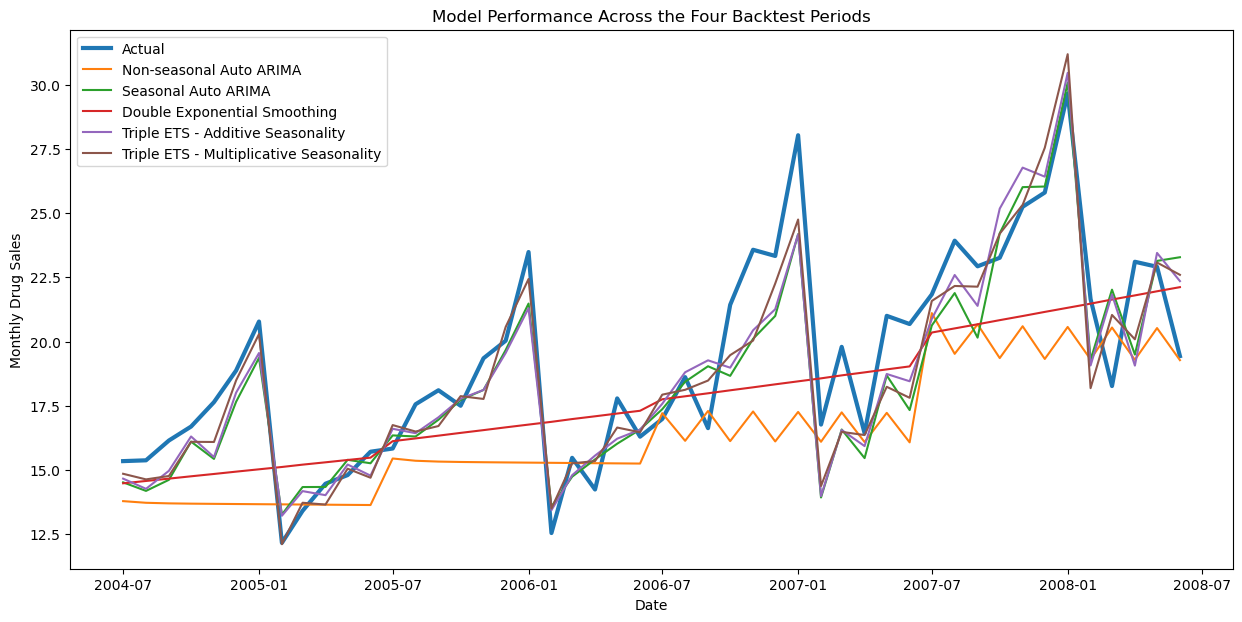

In [57]:
# All model forecasts are plotted together against the actual test data to compare their
# performance efficiently across the four backtest periods.

plt.figure(figsize=(15, 7))

# Actual test data
plt.plot(
    actual_df['Date'],
    actual_df['Actual'],
    label='Actual',
    linewidth=3
)

# Forecasts from all models
for model_name in all_forecasts_df['Model'].unique():

    model_df = all_forecasts_df[
        all_forecasts_df['Model'] == model_name
    ].sort_values('Date')

    plt.plot(
        model_df['Date'],
        model_df['Forecast'],
        label=model_name
    )

plt.title('Model Performance Across the Four Backtest Periods')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()

# Part 5 - Final Model Selection and Forecast

Based on the backtesting results, I would select the **Triple Exponential Smoothing model with Multiplicative Seasonality** to forecast the next 12 months.

Across the four backtest periods, this model achieved the lowest average RMSE (1.534), MAE (1.309), and MAPE (6.65%) among all five models. The backtest plot also shows that it follows the recurring seasonal peaks and troughs closely.

The multiplicative seasonal structure is appropriate because the magnitude of the seasonal fluctuations tends to increase as the overall level of drug sales increases. Therefore, the Triple ETS model with multiplicative seasonality provides the best combination of forecast accuracy and ability to capture the seasonal pattern in the data.

In [58]:
# Next 12-Month Forecast
final_model = ExponentialSmoothing(
    drug_sales_df['value'],
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

final_forecast = final_model.forecast(12)

final_forecast

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2008-07-01    23.832522
2008-08-01    24.814942
2008-09-01    24.502944
2008-10-01    26.308006
2008-11-01    27.707246
2008-12-01    29.706509
2009-01-01    33.708113
2009-02-01    20.651534
2009-03-01    22.196394
2009-04-01    22.571616
2009-05-01    25.010414
2009-06-01    23.729535
Freq: MS, dtype: float64

In [59]:
forecast_dates = pd.date_range(
    start=drug_sales_df.index.max() + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

In [60]:
final_forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast': final_forecast.values
})

final_forecast_df

,Date,Forecast
0,2008-07-01,23.832522
1,2008-08-01,24.814942
2,2008-09-01,24.502944
3,2008-10-01,26.308006
4,2008-11-01,27.707246
5,2008-12-01,29.706509
6,2009-01-01,33.708113
7,2009-02-01,20.651534
8,2009-03-01,22.196394
9,2009-04-01,22.571616


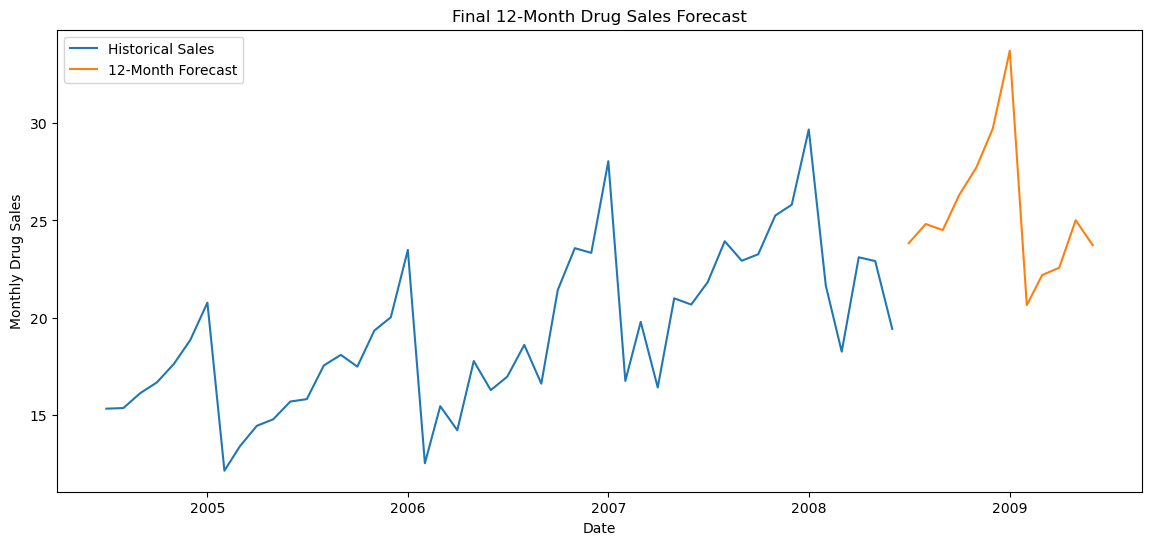

In [61]:
recent_data = drug_sales_df.loc['2004-07-01':]

plt.figure(figsize=(14, 6))

plt.plot(
    recent_data.index,
    recent_data['value'],
    label='Historical Sales'
)

plt.plot(
    final_forecast_df['Date'],
    final_forecast_df['Forecast'],
    label='12-Month Forecast'
)

plt.title('Final 12-Month Drug Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Monthly Drug Sales')
plt.legend()
plt.show()